In [ ]:
import uuid
from db import engine, admin_engine
from style import setup_style
from stop_words import STOP_WORDS
from lyrics_helpers import (
    compute_lyric_embeddings, find_best_k, cluster_lyrics, compute_lyric_umap,
    label_lyric_clusters, save_lyric_clusters,
    plot_lyric_umap, plot_cluster_sizes, plot_audio_lyric_cross, show_cluster_sample,
)
setup_style()

K_MIN          = 5
K_MAX          = 40
CLUSTER_METHOD = 'kmeans'
MODEL_NAME     = 'paraphrase-multilingual-MiniLM-L12-v2'
RUN_ID         = f'lyric-{str(uuid.uuid4())[:8]}'

In [ ]:
df_lyrics, X = compute_lyric_embeddings(engine, MODEL_NAME)

Testando K de 5 a 40...
  K=40  silhouette=0.0275
Melhor K: 5  (silhouette=0.0785)


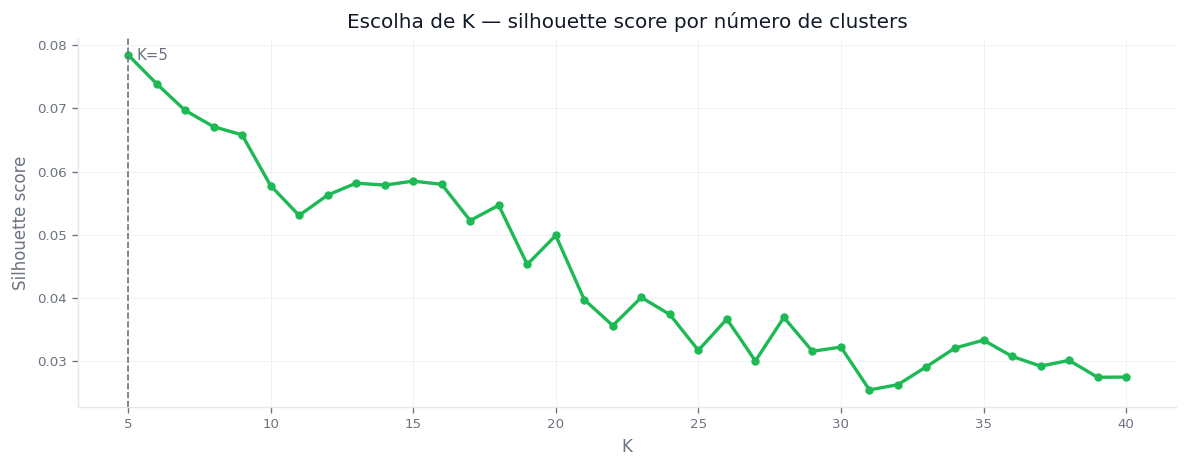

In [ ]:
# N_CLUSTERS = find_best_k(X, k_min=K_MIN, k_max=K_MAX)
N_CLUSTERS=10

In [ ]:
df_lyrics = cluster_lyrics(df_lyrics, X, n_clusters=N_CLUSTERS, method=CLUSTER_METHOD)

NameError: name 'df_lyrics' is not defined

In [3]:
df_lyrics = compute_lyric_umap(df_lyrics, X)

NameError: name 'df_lyrics' is not defined

In [ ]:
df_lyrics, cluster_labels = label_lyric_clusters(df_lyrics, X, STOP_WORDS)

In [ ]:
plot_lyric_umap(df_lyrics)
plot_cluster_sizes(df_lyrics)

In [ ]:
show_cluster_sample(df_lyrics, cluster_id=0)

In [ ]:
save_lyric_clusters(df_lyrics, RUN_ID, admin_engine)

In [ ]:
plot_audio_lyric_cross(engine)